In [1]:
import importlib
import io
from contextlib import redirect_stdout

import pandas as pd
import matplotlib.pyplot as plt

import Modelos
import Estrategia as Estrategias

from UniversoActivos import UniversoActivosDinamico
from ProveedorDatos import YFinanceProvider
from VariablesTransformation import FeatureEngineer
from Backtest import BacktestEngine
from auxiliary_functions import build_metrics_table

RandomForestModel = Modelos.RandomForestModel
XGBoostModel = Modelos.XGBoostModel

EstrategiaMLEquiponderada = Estrategias.EstrategiaMLEquiponderada
EstrategiaMarkI = Estrategias.EstrategiaMarkI
EstrategiaMLMinVarAlphaTilt = Estrategias.EstrategiaMLMinVarAlphaTilt

In [2]:
import pandas as pd
import requests

def get_eurostoxx50_tickers():
    url = 'https://en.wikipedia.org/wiki/EURO_STOXX_50'
    
    # Añadimos una cabecera para simular un navegador real
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
    }
    
    # Hacemos la petición con requests
    response = requests.get(url, headers=headers)
    
    # Pasamos el contenido HTML (response.text) a pandas
    tables = pd.read_html(response.text)
    
    # Buscamos la tabla que contiene la columna 'Ticker'
    df = next(table for table in tables if 'Ticker' in table.columns)
    
    return df['Ticker'].tolist()

# Ahora ya no debería dar error
tickers = get_eurostoxx50_tickers()
print(f"Total empresas: {len(tickers)}")
print(f"Muestra: {tickers[:5]}")

Total empresas: 50
Muestra: ['ADS.DE', 'ADYEN.AS', 'AD.AS', 'AI.PA', 'AIR.PA']


C:\Users\jpuerta\AppData\Local\Temp\ipykernel_1996\2238497255.py:16: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


[************          24%                       ]  13 of 55 completed$STLA.MI: possibly delisted; no timezone found
[*********************100%***********************]  55 of 55 completed

1 Failed download:
['STLA.MI']: possibly delisted; no timezone found
[*************         27%                       ]  15 of 55 completed$STLA.MI: possibly delisted; no timezone found
[*********************100%***********************]  55 of 55 completed

1 Failed download:
['STLA.MI']: possibly delisted; no timezone found
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:48: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping

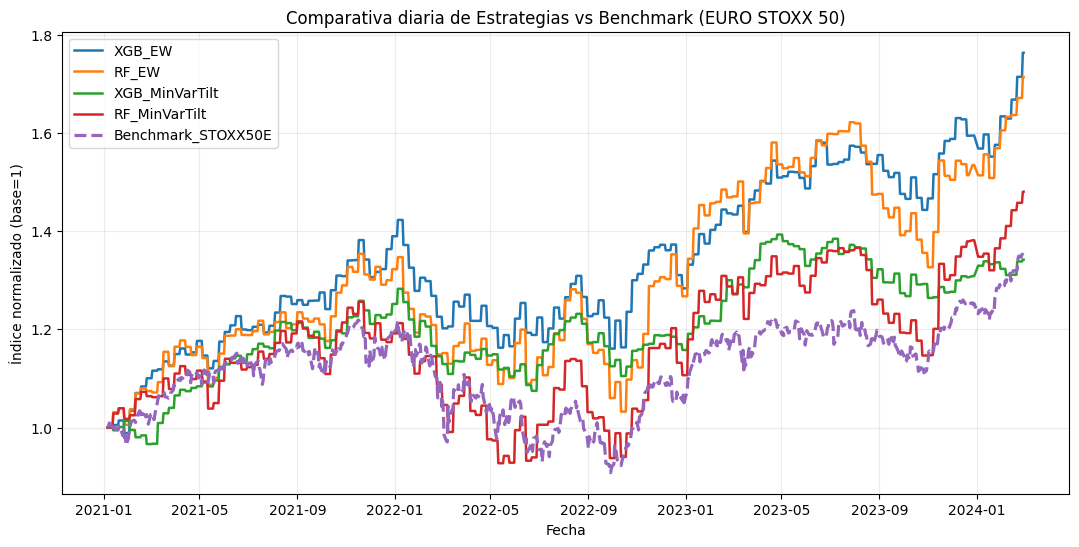

,XGB_EW,RF_EW,XGB_MinVarTilt,RF_MinVarTilt,Benchmark_STOXX50E
Rentabilidad total,76.34%,71.38%,34.21%,48.04%,35.08%
Rentabilidad anualizada,19.62%,18.55%,9.74%,13.19%,9.96%
Volatilidad anualizada,16.89%,22.00%,11.92%,22.71%,17.87%
Sharpe,1.15,0.88,0.84,0.66,0.62
Sortino,1.79,1.38,1.29,1.01,0.88
Max Drawdown,-18.42%,-23.73%,-16.20%,-26.17%,-25.50%
Calmar,1.07,0.78,0.60,0.50,0.39
Mejor periodo,6.23%,10.42%,4.87%,11.02%,7.44%
Peor periodo,-5.16%,-9.17%,-3.75%,-8.76%,-4.96%


In [8]:
# --- Config STOXX50 (como en tu notebook) ---
start_date = "2021-01-01"
end_date = "2024-03-01"

universo = UniversoActivosDinamico(
    tickers_actuales=tickers,
    start_date=start_date,
    end_date=end_date,
    csv_cambios_path=r"eurostoxx50_historico_cambios.csv"
)
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio=5, ticker_indice="SPY")

# --- Define estrategias ---
estrategias = {
    "XGB_EW": EstrategiaMLEquiponderada(
        modelo=XGBoostModel(n_estimators=180, max_depth=3, class_weight=None, random_state=42, positive_class_weight=5.0),
        n_activos_obj=10,
        umbral_salida=15
    ),
    "RF_EW": EstrategiaMLEquiponderada(
        modelo=RandomForestModel(n_estimators=180, max_depth=3, class_weight=None, random_state=42, positive_class_weight=5.0),
        n_activos_obj=10,
        umbral_salida=15
    ),
    "XGB_MinVarTilt": EstrategiaMLMinVarAlphaTilt(
        modelo=XGBoostModel(n_estimators=300, max_depth=4, positive_class_weight=8.0),
        n_activos_obj=10,
        umbral_salida=15,
        p_neutral=0.55,
        alpha_scale=1.0,
        lambda_risk=3.0,
        lambda_tc=0.001,
        w_max=0.15,
        turnover_max=0.20,
        no_trade_band=0.002,
        coste_transaccion=0.0005,
        utility_buffer=0.0001,
        min_hist_obs=26
    ),
    "RF_MinVarTilt": EstrategiaMLMinVarAlphaTilt(
        modelo=RandomForestModel(n_estimators=180, max_depth=3, class_weight=None, random_state=42, positive_class_weight=5.0),
        n_activos_obj=10,
        umbral_salida=15,
        p_neutral=0.55,
        alpha_scale=1.0,
        lambda_risk=3.0,
        lambda_tc=0.001,
        w_max=0.15,
        turnover_max=0.20,
        no_trade_band=0.002,
        coste_transaccion=0.0005,
        utility_buffer=0.0001,
        min_hist_obs=26
    ),
}

# --- Corre backtests y guarda series ---
series_comp = {}
errores = {}

for nombre, estrategia in estrategias.items():
    try:
        engine = BacktestEngine(
            universo=universo,
            proveedor=proveedor,
            feature_engineer=fe,
            estrategia=estrategia,
            start_date=start_date,
            end_date=end_date,
            len_ventana=4,
            nominal=10_000_000
        )
        # silencia prints de "Modelo entrenado en fecha..."
        with redirect_stdout(io.StringIO()):
            serie = engine._run().set_index("Fecha")["Valor cartera"].sort_index()
        series_comp[nombre] = serie
    except Exception as e:
        errores[nombre] = str(e)

# --- Benchmark diario STOXX50 ---
df_bmk = proveedor.download_prices_daily(
    ["^STOXX50E"], start_date=start_date, end_date=end_date
).copy()
df_bmk["Fecha"] = pd.to_datetime(df_bmk["Fecha"])
serie_bmk_daily = (
    df_bmk[df_bmk["Ticker"] == "^STOXX50E"]
    .set_index("Fecha")["Precio_Close"]
    .sort_index()
)

# --- Panel diario: estrategias (weekly) -> daily con ffill ---
# Tomamos el calendario diario del benchmark (puedes usar bdate_range si prefieres)
daily_index = serie_bmk_daily.index

panel_daily = pd.DataFrame(index=daily_index)

for nombre, serie in series_comp.items():
    # serie estrategia viene semanal desde engine._run()
    panel_daily[nombre] = serie.reindex(daily_index).ffill()

panel_daily["Benchmark_STOXX50E"] = serie_bmk_daily.reindex(daily_index).ffill()

# Limpieza y normalización base 1
panel_daily = panel_daily.dropna(how="any")
panel_daily = panel_daily / panel_daily.iloc[0]

# --- Gráfica única diaria ---
plt.figure(figsize=(13, 6))
for col in panel_daily.columns:
    style = "--" if "Benchmark" in col else "-"
    lw = 2.3 if "Benchmark" in col else 1.8
    plt.plot(panel_daily.index, panel_daily[col], linestyle=style, linewidth=lw, label=col)

plt.title("Comparativa diaria de Estrategias vs Benchmark (EURO STOXX 50)")
plt.xlabel("Fecha")
plt.ylabel("Índice normalizado (base=1)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# --- Tabla única de métricas ---
metrics_view = build_metrics_table(
    {c: panel_daily[c] for c in panel_daily.columns},
    periods_per_year=252,
    rf_annual=0.0
).T

pct_rows = {
    "Rentabilidad total", "Rentabilidad anualizada", "Volatilidad anualizada",
    "Max Drawdown", "Win rate", "Mejor periodo", "Peor periodo"
}
metrics_view = metrics_view.apply(
    lambda row: row.map(lambda x: f"{x:.2%}") if row.name in pct_rows
    else row.map(lambda x: f"{x:.2f}"),
    axis=1
)

display(metrics_view)

if errores:
    print("Estrategias con error:")
    for k, v in errores.items():
        print(f"- {k}: {v}")